Rate function:  Ψ(δ) = τ(ρ)² · recal / (2 σ²(R_lag, z))
where R_lag = χ √(1+δ) θ₁  (mass conservation, cylindrical collapse).

Variance:  σ²(R, z) = (1/2π) ∫ k dk P(k, z) |W(kR)|²   
with W = top_hat_filter or starlet_filter.

SCGF:  φ_κ(λ) = ∫dχ max_δ { λ W(χ) δ − Ψ(δ; R(χ), z) }   

In [30]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../src')

from wale.LoadSimulations import get_smoothed_app_pdf, get_smoothed_pdf
from wale.InitializeVariables import InitialiseVariables
from wale.VarianceCalculator import Variance
from wale.ComputePDF import computePDF
from wale.RateFunction import get_scaled_cgf, get_scaled_cgf_1cell
from wale.CriticalPoints import find_critical_points_for_cosmo, find_lambda_range_1cell

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading Simulation Map

the shape of the data is  (1937, 1937)
the pixel size in arcmin is  0.3097573567372225


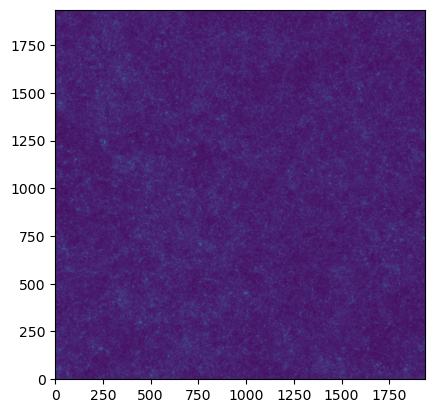

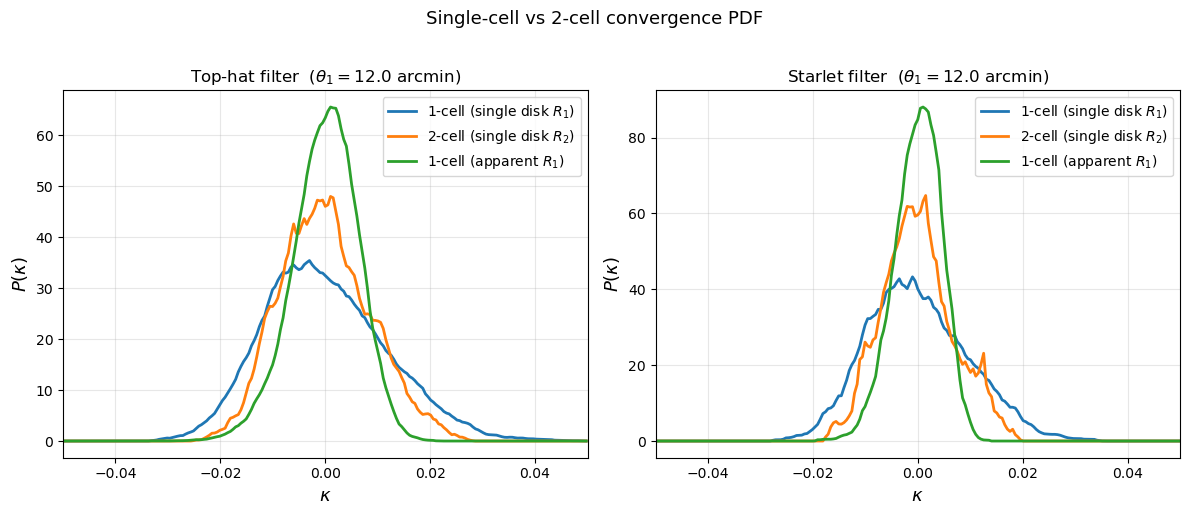

In [31]:
path = '../data/SLICS/2.007kappa_weight.dat_LOS400'
# import astropy units
import astropy.units as u
from skimage.transform import downscale_local_mean
def load_slics_data(file_path, angle=None):
        """
        Load data for the SLICS simulation (from binary or .dat_LOS files).
        
        Parameters:
        -----------
        file_path : str
            Path to the SLICS data file.
        angle : float, optional
            A user-defined angle for the data.
        
        Returns:
        --------
        tuple : (data, angle)
            The data array and corresponding angular resolution.
        """
        npix = 7745 
        with open(file_path, 'rb') as f:
            data_bin = np.fromfile(f, dtype=np.float32)
            data = np.reshape(data_bin, [npix, npix])
        data *= 64.0

        if angle is not None:
            return data, angle * u.deg
        
sim_data, angle_deg = load_slics_data(path, angle=10.0)
data_downscaled = downscale_local_mean(sim_data-np.mean(sim_data), (4, 4))
plt.imshow(data_downscaled, origin='lower')
pixsize = 10.*60/data_downscaled.shape[0] #in arcmin
theta1 = 12.0 #in arcmin
theta2 = 2*theta1 #in arcmin
winrad1 = theta1/pixsize
winrad2 = theta2/pixsize
print("the shape of the data is ", data_downscaled.shape)
print("the pixel size in arcmin is ", pixsize)

binedges = np.linspace(-0.05, 0.05, 200)
center = (binedges[:-1] + binedges[1:])/2
binedges1_th, counts1_th, difference_map1_th = get_smoothed_pdf(data_downscaled, winrad1, binedges, filter_type='tophat')
binedges2_th, counts2_th, difference_map2_th = get_smoothed_pdf(data_downscaled, winrad2, binedges, filter_type='tophat')
binedges1_starlet, counts1_starl, difference_map1_starl = get_smoothed_pdf(data_downscaled, winrad1, binedges, filter_type='starlet')
binedges2_starlet, counts2_starl, difference_map2_starl = get_smoothed_pdf(data_downscaled, winrad2, binedges, filter_type='starlet')

binedges1_app_th, counts1_app_th, difference_map1_app_th = get_smoothed_app_pdf(data_downscaled, winrad1, binedges, filter_type='tophat')
binedges1_app_starlet, counts1_app_starlet, difference_map1_app_starlet = get_smoothed_app_pdf(data_downscaled, winrad1, binedges, filter_type='starlet')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (k1c, p1c, k2c, p2c,k3c, p3c, label) in zip(
    axes,
    [
        (center, counts1_th, center, counts2_th, center, counts1_app_th, 'Top-hat'),
        (center, counts1_starl, center, counts2_starl, center, counts1_app_starlet, 'Starlet'),
    ],
):
    

    ax.plot(k1c, p1c, lw=2, label='1-cell (single disk $R_1$)')
    ax.plot(k2c, p2c, lw=2, label='2-cell (single disk $R_2$)')
    ax.plot(k3c, p3c, lw=2, label='1-cell (apparent $R_1$)')
    ax.set_xlabel(r'$\kappa$', fontsize=13)
    ax.set_ylabel(r'$P(\kappa)$', fontsize=13)
    ax.set_title(f'{label} filter  ($\\theta_1={theta1}$ arcmin)')
    ax.legend()
    ax.set_xlim(-0.05, 0.05)
    ax.grid(True, alpha=0.3)

plt.suptitle('Single-cell vs 2-cell convergence PDF', y=1.02, fontsize=13)
plt.tight_layout()
# plt.savefig('single_cell_pdf_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


## 1. Parameters

In [32]:
# Cosmology (SLICS-like)
h      = 0.6898
Om     = 0.2905
# Ob     = 0.0473
# Oc     = Om - Ob
Oc     = 0.2432
Ob     = Om - Oc
w0     = -1.0
wa     = 0.0
sigma8 = 0.8364

# Survey
tomo_bin  = 3                                          # tomographic bin
nz_file   = None
zs = 2.07
nplanes   = 8
seed      = 42

# k-grid
kmin = 1e-3
kmax = 1.
dk   = 0.001

# Lambda grid will be derived from critical points after init (see cell below)
nlambdas = 61

print(f'theta1 = {theta1} arcmin,  tomo bin = {tomo_bin}')

theta1 = 12.0 arcmin,  tomo bin = 3


## 2. Initialise variables

In [33]:
variables = InitialiseVariables(
    h=h, Oc=Oc, Ob=Ob, w=w0, wa=wa, sigma8=sigma8,
    dk=dk, kmin=kmin, kmax=kmax,
    nz_file=nz_file,
    zs=zs,
    variability=False,
    theta1=theta1,
    nplanes=nplanes,
    numberofrealisations=1,
)
# variables.recal_value = 1.0

print(f'chi range: [{variables.chis.min():.0f}, {variables.chis.max():.0f}] Mpc')
print(f'theta1_radian = {variables.theta1_radian:.5f} rad')
print(f'theta2_radian = {variables.theta2_radian:.5f} rad  (only used for 2-cell)')

pk_fid = variables.cosmo.pnl
# Lambda ranges are computed per cell-type in cells 4, 5, 6 below using
# find_lambda_range_1cell (1-cell) and find_critical_points_for_cosmo (2-cell).

   Using scalar spectral index ns = 0.973

Initialised Cosmology:
  h = 0.6898, Oc = 0.2432, Ob = 0.04729999999999998, w = -1.0, wa = 0.0, sigma8 = 0.8364
  k-range: [0.001, 1.0] with step dk = 0.001

the angles are:  0.0034906585039886587  and  0.0069813170079773175
      Variability: disabled
chi range: [100, 4740] Mpc
theta1_radian = 0.00349 rad
theta2_radian = 0.00698 rad  (only used for 2-cell)


## 3. Compute single-cell variance σ²_κ

For the single-cell case σ²_κ = ∫ dχ W²(χ) σ²(R₁=χθ₁, z), **not** the annulus.

In [34]:
for filter_type in ('tophat', 'starlet'):
    pk_fid = variables.cosmo.pnl
    var    = Variance(variables.cosmo, filter_type=filter_type, pk=pk_fid)

    # 2-cell (annulus) variance
    sig2_2cell = float(np.sum(
        variables.dchi * variables.lensingweights**2 * np.array([
            float(var.get_sig_slice(z, chi*variables.theta1_radian,
                                        chi*variables.theta2_radian))
            for z, chi in zip(variables.redshifts, variables.chis)
        ])
    ))

    # 1-cell variance: σ²(R₁, R₁) only
    sig2_1cell = float(np.sum(
        variables.dchi * variables.lensingweights**2 * np.array([
            float(var.get_sig_slice_1cell(z, chi*variables.theta1_radian))
            for z, chi in zip(variables.redshifts, variables.chis)
        ])
    ))

    print(f'{filter_type:8s}  sig2_2cell={sig2_2cell:.4e}  sig2_1cell={sig2_1cell:.4e}')
    print(f'           ratio 1cell/2cell = {sig2_1cell/sig2_2cell:.3f}')
    print("the map var for R1 apparent is:", np.var(difference_map1_app_th if filter_type=='tophat' else difference_map1_app_starlet))
    print("the map var for R1 is:", np.var(difference_map1_th if filter_type=='tophat' else difference_map1_starl))


tophat    sig2_2cell=3.6307e-05  sig2_1cell=1.3339e-04
           ratio 1cell/2cell = 3.674
the map var for R1 apparent is: 3.9150284e-05
the map var for R1 is: 0.00013780725
starlet   sig2_2cell=1.9072e-05  sig2_1cell=9.2158e-05
           ratio 1cell/2cell = 4.832
the map var for R1 apparent is: 2.0280422e-05
the map var for R1 is: 9.3518785e-05


## 4. Compute single-cell PDF - tophat

1-cell λ range (tophat): [-135.73, 135.73]
Computing single-cell PDF (tophat)...


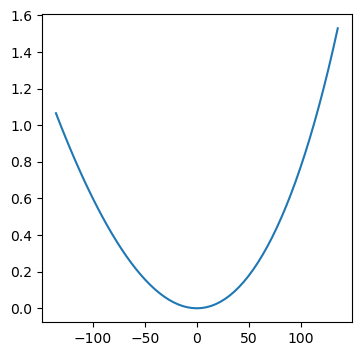

Done.


In [35]:
filter_type = 'tophat'
var_nl_th = Variance(variables.cosmo, filter_type=filter_type, pk=variables.cosmo.pnl)
var_l_th  = Variance(variables.cosmo, filter_type=filter_type, pk=variables.cosmo.plin)

# 1-cell: no simulation recal — per-slice r_j = σ²_nl/σ²_l is computed internally
lam_min_1c, lam_max_1c = find_lambda_range_1cell(variables, var_l_th, var_nl_th)
lambdas_1c = np.linspace(lam_min_1c, lam_max_1c, nlambdas)
variables.lambdas = lambdas_1c
print(f'1-cell λ range (tophat): [{lam_min_1c:.2f}, {lam_max_1c:.2f}]')

kappa_edges = np.linspace(-0.06, 0.06, 801)
kappa_bins  = 0.5 * (kappa_edges[:-1] + kappa_edges[1:])

print('Computing single-cell PDF (tophat)...')
pdf_th = computePDF(variables, var_nl_th, kappa=kappa_bins, plot_scgf=True,
                    single_cell=True, variance_linear=var_l_th)
kappa_th = np.array(pdf_th.kappa_values)
p_th     = np.array(pdf_th.pdf_values)
print('Done.')

## 5. Compute single-cell PDF — starlet

In [36]:
filter_type = 'starlet'
var_nl_st = Variance(variables.cosmo, filter_type=filter_type, pk=variables.cosmo.pnl)
var_l_st  = Variance(variables.cosmo, filter_type=filter_type, pk=variables.cosmo.plin)

lam_min_1c_st, lam_max_1c_st = find_lambda_range_1cell(variables, var_l_st, var_nl_st)
lambdas_1c_st = np.linspace(lam_min_1c_st, lam_max_1c_st, nlambdas)
variables.lambdas = lambdas_1c_st
print(f'1-cell λ range (starlet): [{lam_min_1c_st:.2f}, {lam_max_1c_st:.2f}]')

print('Computing single-cell PDF (starlet)...')
pdf_st = computePDF(variables, var_nl_st, kappa=kappa_bins, plot_scgf=False,
                    single_cell=True, variance_linear=var_l_st)
kappa_st = np.array(pdf_st.kappa_values)
p_st     = np.array(pdf_st.pdf_values)
print('Done.')

1-cell λ range (starlet): [-205.00, 205.00]
Computing single-cell PDF (starlet)...
Done.


## 6. Compute 2-cell PDFs for comparison

In [37]:
# ── 2-cell tophat ──────────────────────────────────────────────────────────────
var_th2 = Variance(variables.cosmo, filter_type='tophat', pk=variables.cosmo.pnl)

sigmasq_map_2c_th = float(np.sum(
    variables.dchi * variables.lensingweights**2 * np.array([
        float(var_th2.get_sig_slice(z, chi * variables.theta1_radian,
                                        chi * variables.theta2_radian))
        for z, chi in zip(variables.redshifts, variables.chis)
    ])
))
sig_sim_2c_th = np.var(difference_map1_app_th)
variables.recal_value = sigmasq_map_2c_th / sig_sim_2c_th
print(f'sig2_2cell LDT (tophat)  = {sigmasq_map_2c_th:.4e}')
print(f'sig2_2cell sim (tophat)  = {sig_sim_2c_th:.4e}')
print(f'recal_value   (tophat)   = {variables.recal_value:.4f}')

sp_th, ln_th = find_critical_points_for_cosmo(
    variables, var_th2, ngrid_critical=5, plot=False, min_z=0, max_z=5
)
lambdas_2c_th = (np.linspace(ln_th, sp_th, nlambdas)
                 if (sp_th is not None and ln_th is not None)
                 else np.linspace(-400, 1400, nlambdas))
print(f'2-cell lambda range (tophat): [{lambdas_2c_th[0]:.2f}, {lambdas_2c_th[-1]:.2f}]')
variables.lambdas = lambdas_2c_th

print('Computing 2-cell PDF (tophat)...')
pdf_th2   = computePDF(variables, var_th2, kappa=kappa_bins, single_cell=False)
kappa_th2 = np.array(pdf_th2.kappa_values)
p_th2     = np.array(pdf_th2.pdf_values)

print('Done.')

# ── 2-cell starlet ─────────────────────────────────────────────────────────────
var_st2 = Variance(variables.cosmo, filter_type='starlet', pk=variables.cosmo.pnl)

sigmasq_map_2c_st = float(np.sum(
    variables.dchi * variables.lensingweights**2 * np.array([
        float(var_st2.get_sig_slice(z, chi * variables.theta1_radian,
                                        chi * variables.theta2_radian))
        for z, chi in zip(variables.redshifts, variables.chis)
    ])
))
sig_sim_2c_st = np.var(difference_map1_app_starlet)
variables.recal_value = sigmasq_map_2c_st / sig_sim_2c_st
print(f'sig2_2cell LDT (starlet) = {sigmasq_map_2c_st:.4e}')
print(f'sig2_2cell sim (starlet) = {sig_sim_2c_st:.4e}')
print(f'recal_value   (starlet)  = {variables.recal_value:.4f}')

sp_st, ln_st = find_critical_points_for_cosmo(
    variables, var_st2, ngrid_critical=5, plot=False, min_z=0, max_z=5
)
lambdas_2c_st = (np.linspace(ln_st, sp_st, nlambdas)
                 if (sp_st is not None and ln_st is not None)
                 else np.linspace(-400, 1400, nlambdas))
print(f'2-cell lambda range (starlet): [{lambdas_2c_st[0]:.2f}, {lambdas_2c_st[-1]:.2f}]')
variables.lambdas = lambdas_2c_st

print('Computing 2-cell PDF (starlet)...')
pdf_st2   = computePDF(variables, var_st2, kappa=kappa_bins, single_cell=False)
kappa_st2 = np.array(pdf_st2.kappa_values)
p_st2     = np.array(pdf_st2.pdf_values)
print('Done.')

sig2_2cell LDT (tophat)  = 3.6307e-05
sig2_2cell sim (tophat)  = 3.9150e-05
recal_value   (tophat)   = 0.9274
2-cell lambda range (tophat): [-113.17, 606.24]
Computing 2-cell PDF (tophat)...
Done.
sig2_2cell LDT (starlet) = 1.9072e-05
sig2_2cell sim (starlet) = 2.0280e-05
recal_value   (starlet)  = 0.9404
2-cell lambda range (starlet): [-338.46, 1369.51]
Computing 2-cell PDF (starlet)...
Done.


## 7. Plot: single-cell vs 2-cell, tophat and starlet

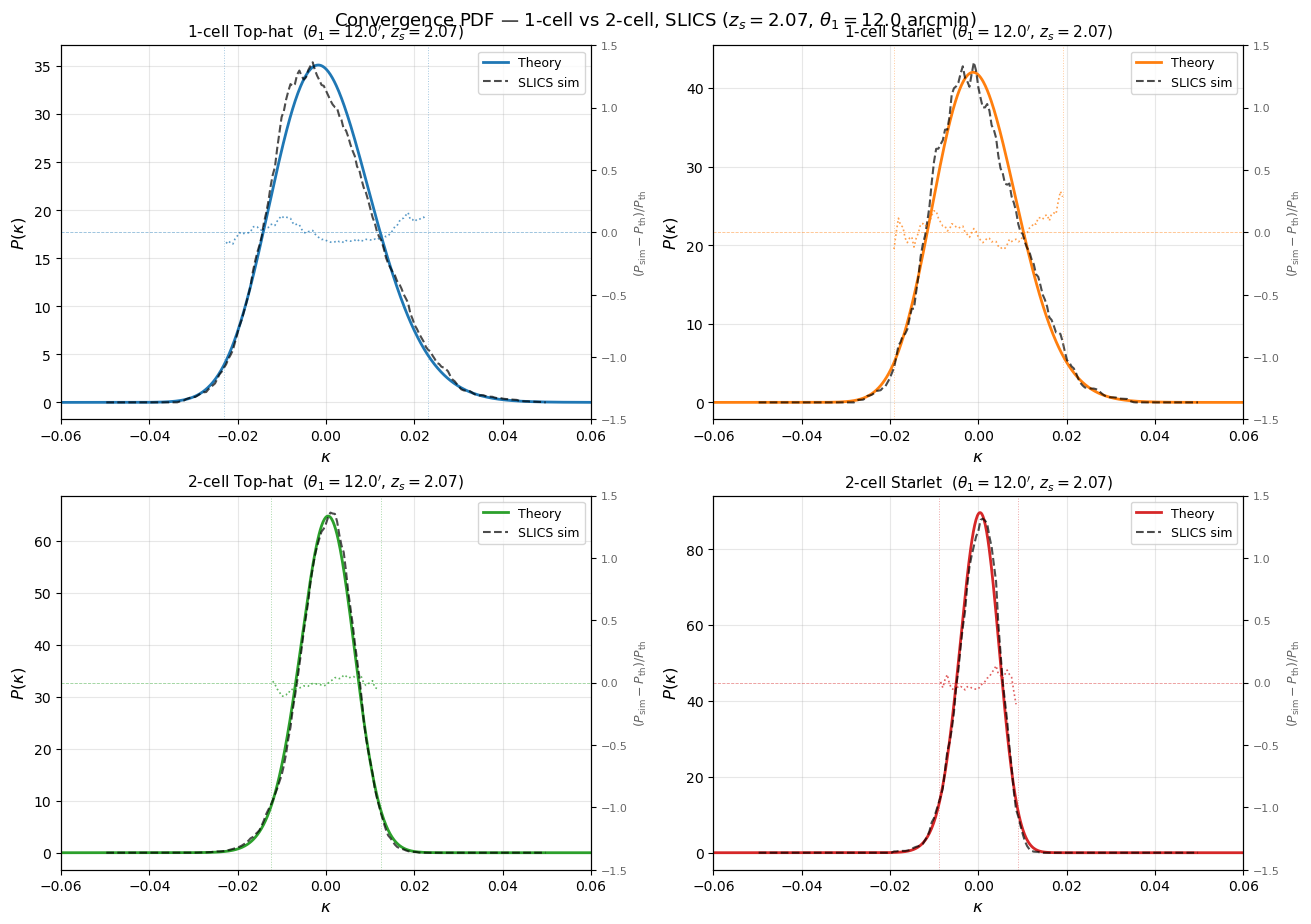

In [38]:
from scipy.interpolate import interp1d

def _moments(kappa, pdf):
    """Variance, mean and skewness from a sampled PDF (trapezoid integration)."""
    norm  = np.trapezoid(pdf, kappa)
    pdf_n = pdf / norm
    mu1   = np.trapezoid(kappa       * pdf_n, kappa)
    mu2   = np.trapezoid(kappa**2    * pdf_n, kappa) - mu1**2
    mu3   = np.trapezoid((kappa-mu1)**3 * pdf_n, kappa)
    sk    = mu3 / mu2**1.5
    return mu1, mu2, sk

def _sim_moments(kappa_c, counts):
    """Moments from histogram counts (already bin-averaged PDF values)."""
    # treat counts as PDF * dk
    dk     = kappa_c[1] - kappa_c[0]
    norm   = np.sum(counts) * dk
    pdf_n  = counts / (norm if norm > 0 else 1.0)
    mu1    = np.sum(kappa_c       * pdf_n) * dk
    mu2    = np.sum(kappa_c**2    * pdf_n) * dk - mu1**2
    mu3    = np.sum((kappa_c-mu1)**3 * pdf_n) * dk
    sk     = mu3 / mu2**1.5
    return mu1, mu2, sk

def add_residual(ax, kappa_th, p_th, kappa_sim, p_sim, sigma_th, color):
    """
    Overlay (sim - th)/th residual on a twin y-axis.
    x-range for residual is limited to ±2σ of the theory PDF.
    """
    ax2 = ax.twinx()
    # Interpolate theory onto simulation grid
    f_th  = interp1d(kappa_th, p_th, bounds_error=False, fill_value=0.0)
    p_th_interp = f_th(kappa_sim)
    with np.errstate(divide='ignore', invalid='ignore'):
        resid = np.where(p_th_interp > 1e-8, (p_sim - p_th_interp) / p_th_interp, np.nan)
    mask = (kappa_sim >= -2*sigma_th) & (kappa_sim <= 2*sigma_th)
    ax2.plot(kappa_sim[mask], resid[mask], color=color, lw=1.2, ls=':', alpha=0.75)
    ax2.axhline(0, color=color, lw=0.6, ls='--', alpha=0.5)
    ax2.set_ylabel(r'$(P_{\rm sim}-P_{\rm th})/P_{\rm th}$', fontsize=9, color='0.4')
    ax2.tick_params(axis='y', labelsize=8, labelcolor='0.4')
    ax2.set_ylim(-1.5, 1.5)
    return ax2

# Simulation bins (from data cell)
sim_kappa = center   # bin centres from data loading cell

# Theory σ for each case (used to define 2σ x-range of residuals)
_, var_th_tophat,  _ = _moments(kappa_th,  p_th)
_, var_th_starlet, _ = _moments(kappa_st,  p_st)
_, var_2c_tophat,  _ = _moments(kappa_th2, p_th2)
_, var_2c_starlet, _ = _moments(kappa_st2, p_st2)
sigma_1c_th = np.sqrt(var_th_tophat)
sigma_1c_st = np.sqrt(var_th_starlet)
sigma_2c_th = np.sqrt(var_2c_tophat)
sigma_2c_st = np.sqrt(var_2c_starlet)

# ── Figure: 2 rows × 2 columns ─────────────────────────────────────────────
#   Row 0: 1-cell (tophat | starlet)
#   Row 1: 2-cell (tophat | starlet)
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

configs = [
    # (ax, kappa_th, p_th, sim_kappa, sim_pdf, sigma, title)
    (axes[0,0], kappa_th,  p_th,  sim_kappa, counts1_th,       sigma_1c_th, '1-cell Top-hat'),
    (axes[0,1], kappa_st,  p_st,  sim_kappa, counts1_starl,    sigma_1c_st, '1-cell Starlet'),
    (axes[1,0], kappa_th2, p_th2, sim_kappa, counts1_app_th,   sigma_2c_th, '2-cell Top-hat'),
    (axes[1,1], kappa_st2, p_st2, sim_kappa, counts1_app_starlet, sigma_2c_st, '2-cell Starlet'),
]

colors = ['C0', 'C1', 'C2', 'C3']

for (ax, kt, pt, ks, ps, sig, title), col in zip(configs, colors):
    ax.plot(kt, pt, lw=2, color=col, label='Theory')
    ax.plot(ks, ps, lw=1.5, ls='--', color='k', alpha=0.7, label='SLICS sim')
    add_residual(ax, kt, pt, ks, ps, sig, col)
    ax.set_xlabel(r'$\kappa$', fontsize=12)
    ax.set_ylabel(r'$P(\kappa)$', fontsize=12)
    ax.set_title(f'{title}  ($\\theta_1={theta1}\'$, $z_s={zs}$)', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlim(-0.06, 0.06)
    ax.grid(True, alpha=0.3)
    # mark ±2σ with thin vertical lines for reference
    ax.axvline(-2*sig, color=col, lw=0.7, ls=':', alpha=0.4)
    ax.axvline(+2*sig, color=col, lw=0.7, ls=':', alpha=0.4)

fig.suptitle(
    f'Convergence PDF — 1-cell vs 2-cell, SLICS ($z_s={zs}$, $\\theta_1={theta1}$ arcmin)',
    fontsize=13, y=1.01
)
plt.savefig('convergence_pdf_1cell_2cell.pdf', bbox_inches='tight')
plt.show()

In [42]:
# ── Moments + L1 norm table: theory vs simulation ────────────────────────────                                     
                                            
def _moments(kappa, pdf):                                                                                           
    norm  = np.trapezoid(pdf, kappa)                                                                                    
    pdf_n = pdf / norm                                                                                              
    mu1   = np.trapezoid(kappa * pdf_n, kappa)                                                                          
    mu2   = np.trapezoid(kappa**2 * pdf_n, kappa) - mu1**2                                                              
    mu3   = np.trapezoid((kappa - mu1)**3 * pdf_n, kappa)                                                               
    return mu1, mu2, mu3 / mu2**1.5                                                                                 
                                            
def _sim_moments(kappa_c, counts):                                                                                  
    dk    = kappa_c[1] - kappa_c[0]                                                                               
    norm  = np.sum(counts) * dk                                                                                     
    pdf_n = counts / (norm if norm > 0 else 1.0)                                                                    
    mu1   = np.sum(kappa_c * pdf_n) * dk                                                                            
    mu2   = np.sum(kappa_c**2 * pdf_n) * dk - mu1**2                                                                
    mu3   = np.sum((kappa_c - mu1)**3 * pdf_n) * dk                                                                 
    return mu1, mu2, mu3 / mu2**1.5         
                                                                                                                    
def _l1(kappa, pdf):                                                                                              
    norm = np.trapezoid(pdf, kappa)                                                                                     
    return float(np.trapezoid(np.abs(kappa) * pdf / norm, kappa))                                                     
                                                                                                                    
def _sim_l1(kappa_c, counts):                                                                                     
    dk   = kappa_c[1] - kappa_c[0]                                                                                  
    norm = np.sum(counts) * dk
    return float(np.sum(np.abs(kappa_c) * counts / (norm if norm > 0 else 1.0)) * dk)                               
                                                                                                                
rows = [                                                                                                            
    ('1-cell Top-hat',  kappa_th,  p_th,  sim_kappa, counts1_th),                                                 
    ('1-cell Starlet',  kappa_st,  p_st,  sim_kappa, counts1_starl),                                                
    ('2-cell Top-hat',  kappa_th2, p_th2, sim_kappa, counts1_app_th),
    ('2-cell Starlet',  kappa_st2, p_st2, sim_kappa, counts1_app_starlet),                                          
]                                                                                                                   
                                                                                                                    
hdr = (f"{'Case':<22} | {'Mean th':>10} {'Mean sim':>10} | "                                                        
        f"{'Var th':>12} {'Var sim':>12} | "                                                                         
        f"{'Skew th':>9} {'Skew sim':>9} | "                                                                         
        f"{'L1 th':>10} {'L1 sim':>10}")                                                                             
sep = '-' * len(hdr)                        
print(sep)                                                                                                          
print(hdr)                                                                                                        
print(sep)                                                                                                          
for (label, kt, pt, ks, ps) in rows:                                                                              
    mu_th,  var_th,  sk_th  = _moments(kt, pt)                                                                      
    mu_sim, var_sim, sk_sim = _sim_moments(ks, ps)                                                                
    l1_th  = _l1(kt, pt)                
    l1_sim = _sim_l1(ks, ps)                                                                                        
    print(                                                                                                          
        f"{label:<22} | "                                                                                           
        f"{mu_th:>10.3e} {mu_sim:>10.3e} | "                                                                        
        f"{var_th:>12.3e} {var_sim:>12.3e} | "                                                                    
        f"{sk_th:>9.3f} {sk_sim:>9.3f} | "                                                                          
        f"{l1_th:>10.4e} {l1_sim:>10.4e}"                                                                         
    )                                                                                                               
print(sep)       

------------------------------------------------------------------------------------------------------------------------
Case                   |    Mean th   Mean sim |       Var th      Var sim |   Skew th  Skew sim |      L1 th     L1 sim
------------------------------------------------------------------------------------------------------------------------
1-cell Top-hat         | -1.305e-06 -5.773e-08 |    1.333e-04    1.378e-04 |     0.316     0.401 | 9.1737e-03 9.3929e-03
1-cell Starlet         |  1.803e-08  4.139e-08 |    9.217e-05    9.354e-05 |     0.256     0.321 | 7.6376e-03 7.7630e-03
2-cell Top-hat         |  1.014e-07  1.058e-08 |    3.913e-05    3.917e-05 |    -0.172    -0.326 | 4.9646e-03 4.9501e-03
2-cell Starlet         | -4.337e-07  3.188e-08 |    2.027e-05    2.030e-05 |    -0.185    -0.365 | 3.5794e-03 3.5963e-03
------------------------------------------------------------------------------------------------------------------------


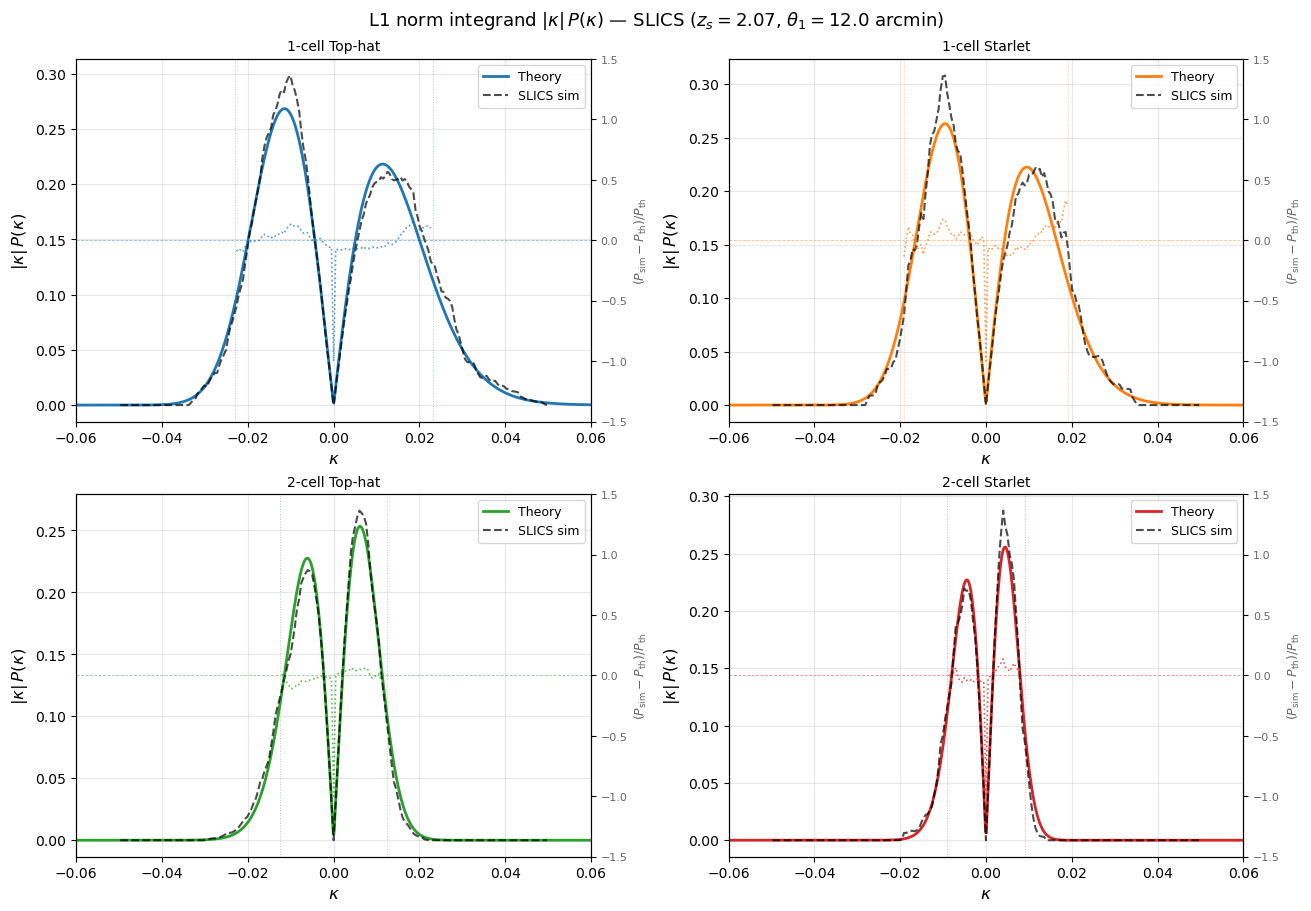

In [39]:
# ── L1 norm integrand |κ| P(κ) vs κ  ─────────────────────────────────────────
# Per-bin L1 = |κ| × P(κ).  PDFs are already normalised so no rescaling needed.
# Layout mirrors the PDF comparison plot: theory line + sim + residuals.

fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

configs_l1 = [
    (axes[0, 0], kappa_th,  p_th,  sim_kappa, counts1_th,         sigma_1c_th, '1-cell Top-hat'),
    (axes[0, 1], kappa_st,  p_st,  sim_kappa, counts1_starl,       sigma_1c_st, '1-cell Starlet'),
    (axes[1, 0], kappa_th2, p_th2, sim_kappa, counts1_app_th,      sigma_2c_th, '2-cell Top-hat'),
    (axes[1, 1], kappa_st2, p_st2, sim_kappa, counts1_app_starlet, sigma_2c_st, '2-cell Starlet'),
]

for (ax, kt, pt, ks, ps, sig, title), col in zip(configs_l1, colors):
    l1_th  = np.abs(kt) * np.array(pt)
    l1_sim = np.abs(ks) * np.array(ps)

    ax.plot(kt, l1_th,  lw=2,   color=col, label='Theory')
    ax.plot(ks, l1_sim, lw=1.5, ls='--', color='k', alpha=0.7, label='SLICS sim')
    add_residual(ax, kt, l1_th, ks, l1_sim, sig, col)

    # L1_th  = float(np.trapz(l1_th, kt))
    # L1_sim = float(np.sum(l1_sim) * (ks[1] - ks[0]))
    ax.set_xlabel(r'$\kappa$', fontsize=12)
    ax.set_ylabel(r'$|\kappa|\,P(\kappa)$', fontsize=12)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=9)
    ax.set_xlim(-0.06, 0.06)
    ax.grid(True, alpha=0.3)
    ax.axvline(-2*sig, color=col, lw=0.7, ls=':', alpha=0.4)
    ax.axvline(+2*sig, color=col, lw=0.7, ls=':', alpha=0.4)

fig.suptitle(
    fr'L1 norm integrand $|\kappa|\,P(\kappa)$ — SLICS ($z_s={zs}$, $\theta_1={theta1}$ arcmin)',
    fontsize=13
)
# plt.savefig('l1norm_comparison.pdf', bbox_inches='tight')
plt.show()


## 8. Diagnostic: SCGF comparison

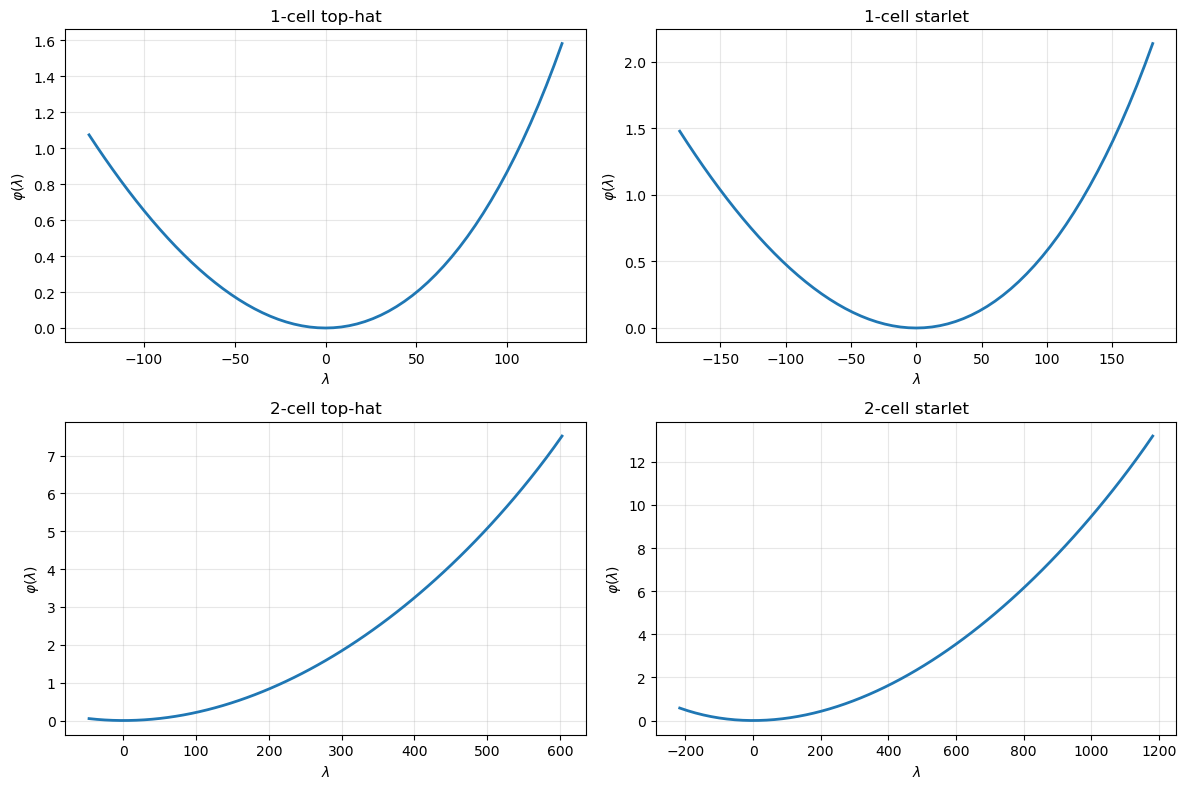

In [34]:
# Lambda arrays from earlier cells:
#   lambdas_1c     — tophat 1-cell  (find_lambda_range_1cell)
#   lambdas_1c_st  — starlet 1-cell (find_lambda_range_1cell)
#   lambdas_2c_th  — tophat 2-cell  (find_critical_points_for_cosmo with tophat recal)
#   lambdas_2c_st  — starlet 2-cell (find_critical_points_for_cosmo with starlet recal)

scgf_1c_th = get_scaled_cgf_1cell(
    variables.theta1_radian,
    variables.redshifts, variables.chis, variables.dchi,
    variables.lensingweights, lambdas_1c,
    Variance(variables.cosmo, "tophat", pk=variables.cosmo.plin),
    Variance(variables.cosmo, "tophat", pk=variables.cosmo.pnl),
)
scgf_1c_st = get_scaled_cgf_1cell(
    variables.theta1_radian,
    variables.redshifts, variables.chis, variables.dchi,
    variables.lensingweights, lambdas_1c_st,
    Variance(variables.cosmo, "starlet", pk=variables.cosmo.plin),
    Variance(variables.cosmo, "starlet", pk=variables.cosmo.pnl),
)

# For 2-cell diagnostics, recal_value must match what was used to find lambdas_2c_*
variables.recal_value = sigmasq_map_2c_th / np.var(difference_map1_app_th)
scgf_2c_th = get_scaled_cgf(
    variables.theta1_radian, variables.theta2_radian,
    variables.redshifts, variables.chis, variables.dchi,
    variables.lensingweights, lambdas_2c_th,
    variables.recal_value,
    Variance(variables.cosmo, "tophat", pk=variables.cosmo.pnl),
)

variables.recal_value = sigmasq_map_2c_st / np.var(difference_map1_app_starlet)
scgf_2c_st = get_scaled_cgf(
    variables.theta1_radian, variables.theta2_radian,
    variables.redshifts, variables.chis, variables.dchi,
    variables.lensingweights, lambdas_2c_st,
    variables.recal_value,
    Variance(variables.cosmo, "starlet", pk=variables.cosmo.pnl),
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, lams, scgf, title in [
    (axes[0, 0], lambdas_1c,    scgf_1c_th, "1-cell top-hat"),
    (axes[0, 1], lambdas_1c_st, scgf_1c_st, "1-cell starlet"),
    (axes[1, 0], lambdas_2c_th, scgf_2c_th, "2-cell top-hat"),
    (axes[1, 1], lambdas_2c_st, scgf_2c_st, "2-cell starlet"),
]:
    ax.plot(lams, np.array(scgf), lw=2)
    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(r"$\varphi(\lambda)$")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()